In [1]:
from scipy.optimize import minimize
from scipy.optimize import direct, Bounds
from smooth_POD_ROM.post_processing import richardson_lucy
from smooth_POD_ROM.pre_processing import smoothen_rowwise
from smooth_POD_ROM.initial_conditions import rectangular_pulse, rect_pulse_sin, saw_tooth, triangle, small_saw_tooth, small_r_pulse
from smooth_POD_ROM.reduced_order_model import optimize_hyperparameters, optimize_sROM, target_function, get_predictions, get_improvement
from smooth_POD_ROM.reduced_order_model import make_data_rw, train_ROM_rw, L2_error_rw, get_data_rw
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
# tmeplate: X_randMU

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 2.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 40

8.030570172000001


In [4]:
def small_saw_tooth(x, mu):
    return saw_tooth(x, mu, w=1/45)

In [5]:
n_x = 5000
x = np.linspace(0, 1, n_x, endpoint=False)
case = {
    "n_x": n_x,
    "shape": x.shape,
    "x": x,
    "dx": x[1] - x[0],

    "n_train": 10,
    "n_test": 25,
    "g": small_saw_tooth, #saw_tooth, #rectangular_pulse,
    "truncate": 12,
    "sigma": 0.08,

    "c": 1,
    "monitor_progress_postprocessing": False,
    "num_iter": 200,
    "monitor_convergence": False,
}

(0.1, 0.2)

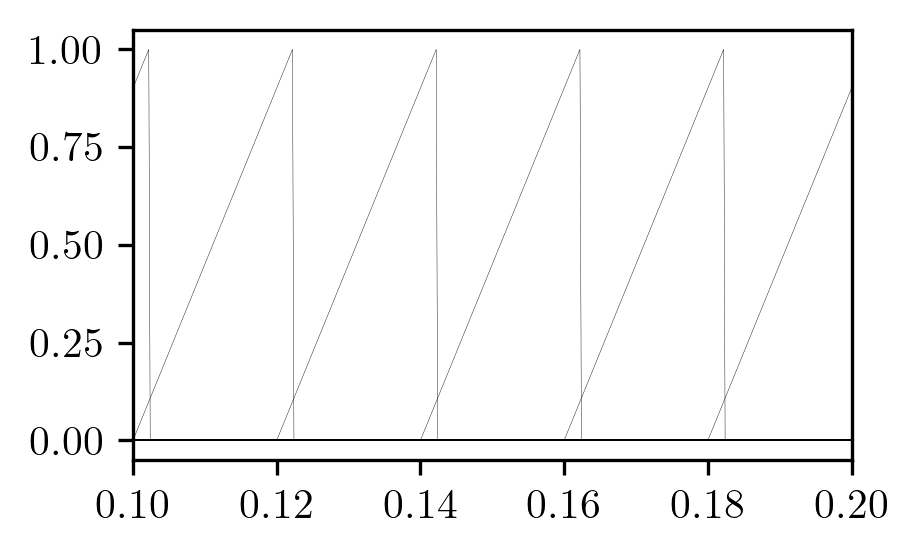

In [6]:
rank = 50
case["rank"] = n_train = rank

mu_train = np.linspace([0], [1], n_train, endpoint=False)
#case["mu_train"] = mu_train

X_train, X_train_s= get_data_rw(mu_train, **case)
for i in range(len(X_train)):
    plt.plot(x, X_train[i], "k-", lw=.1)
plt.xlim(.1, .2)

In [7]:
g = case["g"]

shape = case["shape"]
num_iter1 = 100
num_iter2 = 250

#def estimate_dN():

# num_iter = 200
#NN = np.array([*np.arange(4, 30, 2), *np.arange(30, 150, 10)])
NN = np.array([*np.arange(3, 25, 2), *np.arange(25, 75, 5), *np.arange(80, 200, 10), *np.arange(200, 500, 25)])
dN_ROM = np.zeros(len(NN))
dN_sig = np.zeros((len(NN), 10))

sig = np.zeros((len(NN), 10))
sig[:, 1] = .05/NN**.5
sig[:, 2] = .01/NN**.5
sig[:, 3] = .001/NN**.5
#sig[:, 3] = .4 / (NN)
sig[:, 4] = .3 / (NN)
sig[:, 5] = .2 / (NN)   # this is the one for narrow saw tooth
sig[:, 6] = .1 / (NN)
sig[:, 7] = 10 / (NN**2)
sig[:, 8] = 25 / (NN**2)
sig[:, 9] = 40 / (NN**2)
lbls = ["optimized", ".05/N**.5", ".01/N**.5", ".001/N**.5", "0.3/N", "0.2/N",  "0.1/N", "10/(N**2)", "25/(N**2)", "40/(N**2)"]

for i, rank in enumerate(NN):
    n_train = rank
    print(rank)
    case["num_iter"] = num_iter1
    case["rank"] = rank
    case["n_train"] = n_train
    case["sROM_only"] = True
    
    parameters = optimize_sROM(case)
    sig[i, 0] = parameters[0]
    #sig[i, 0] = 0.02995521

    #for sigS, dN in zip([sig_opt, sig_1, sig_2, sig_3, sig_4], [dN_sig_opt, dN_sig_1, dN_sig_2, dN_sig_3, dN_sig_4]):
    for j in range(10):
        case["sigma"] = sig[i, j]
        mean_ROM, mean_sROM, mean_sROMs = target_function(case)
        dN_sig[i, j] = mean_sROM
        
    dN_ROM[i] = mean_ROM
np.save("./8_dN_ROM.npy", dN_ROM)
np.save("./8_dN_sig.npy", dN_sig)
np.save("./8_sig.npy", sig)
np.save("./8_NN.npy", NN)

3
max: 0.06666666666666667
num_iter, n_train, n_test, sigma_S, c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 25, 0.03333833, -, 0.10510071, 0.08601933, -, -18.1553
num_iter, n_train, n_test, sigma_S, c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 25, 0.05555722, -, 0.10510071, 0.08474121, -, -19.3714
num_iter, n_train, n_test, sigma_S, c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 25, 0.01111944, -, 0.10510071, 0.09214127, -, -12.3305
num_iter, n_train, n_test, sigma_S, c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 25, 0.06296352, -, 0.10510071, 0.08454640, -, -19.5568
num_iter, n_train, n_test, sigma_S, c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 25, 0.04815093, -, 0.10510071, 0.08501789, -, -19.1082
num_iter, n_train, n_test, sigma_S, c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 25, 0.04074463, -, 0.10510071, 0.08541820, -, -18.7273
num_iter, n_train, n_test, sigma_S, c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3,

log log plot
plot sig S opt


In [ ]:
sigma_Ssigma_S

In [8]:
# l = NN<70
# dN_sig[l, 5]

# from scipy.optimize import curve_fit

# def exp_func(x, a, b):
#     return a * np.exp(-b * x)  # No offset (simpler form)

# popt, pcov = curve_fit(exp_func, NN[l], dN_sig[l, 5], p0=(1/12, 300))  # Initial guess: (a=1, b=0.1)
# a_fit, b_fit = popt  # Extract fitted parameters
# print(popt)
# a_fit, b_fit = 1/12, 300
# plt.plot(NN[l], dN_sig[l, 5], "C0x")
# #plt.plot(NN, exp_func(NN, a_fit, b_fit))

[0.03 0.04 0.05 0.06 0.07 0.08 0.09]
[0.1]
[Text(0, 0.03, '0.03'), Text(0, 0.04, ' '), Text(0, 0.05, '0.05'), Text(0, 0.06, ' '), Text(0, 0.07, '0.07'), Text(0, 0.08, ' '), Text(0, 0.09, ' ')]


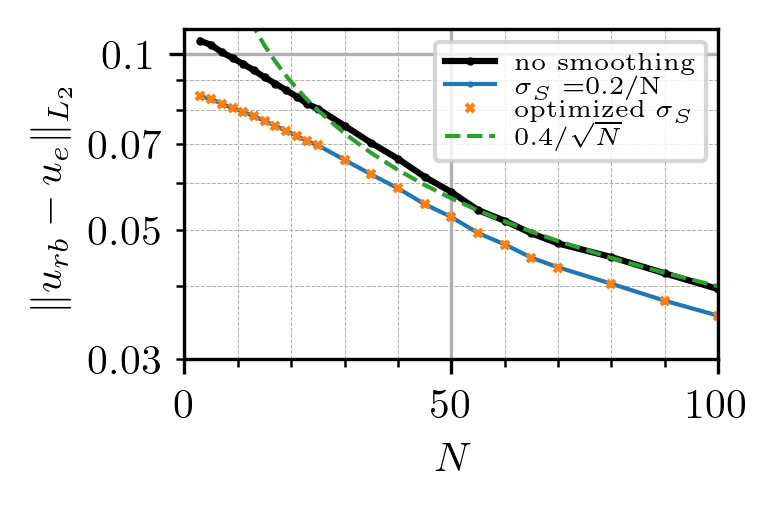

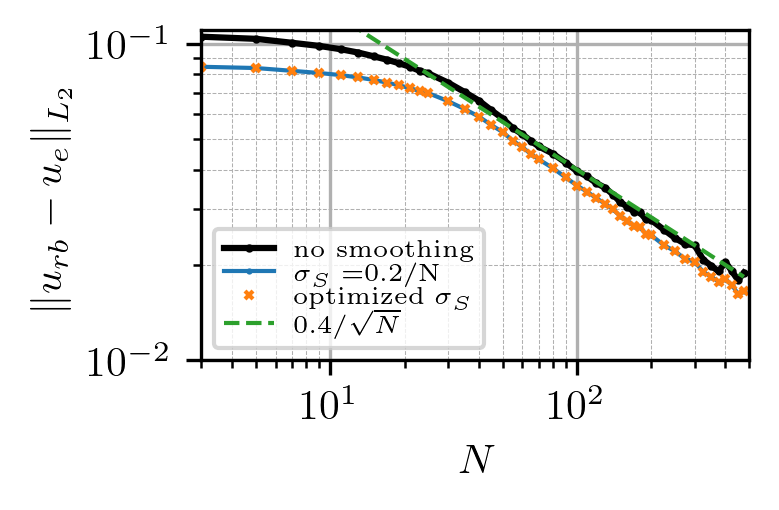

In [9]:
fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))
#plt.plot(NN, esROM, "C1--", ms=2, label="$u_{rb,S}$")
plt.plot(NN, dN_ROM, "k.-", ms=2, label=r"no smoothing")
# for i in [2, 5, 7]: #range(4, 10):
#     plt.plot(NN, dN_sig[:, i], ls="-", marker=".", lw=1, ms=1, label=lbls[i])# r"$u_{\mu,Srb}$"
plt.plot(NN, dN_sig[:, 5], ls="-", marker=".", lw=1, ms=1, label=r"$\sigma_S=$"+lbls[5])# r"$u_{\mu,Srb}$"
#plt.plot(NN, np.exp(-NN/300)/12, "C3--", lw=1, ms=1, label=r"$exp(-N)$")
plt.plot(NN, dN_sig[:, 0], ls="None", marker="x", lw=1, ms=2, label=r"optimized $\sigma_S$")# r"$u_{\mu,Srb}$"
plt.plot(NN, .4/NN**.5, "C2--", lw=1, ms=1, label=r"$0.4/\sqrt{N}$")

plt.ylabel(r"$\|u_{rb}-u_{e}\|_{L_2}$")
plt.xlabel(r"$N$")
# plt.ylim(0, 0.4)
plt.legend()


ax.set_yscale("log")
plt.xlim(0, 100)
plt.ylim(0.03, 0.11)


ax.set_xticks(np.linspace(0, 100, 11, endpoint=True), minor=True)
ax.set_xticks([0, 50, 100], minor=False)

ax.set_yticks(np.linspace(0.03, 0.1, 8, endpoint=True), minor=True)
ax.set_yticks([0.1], minor=False)
ax.set_yticklabels(["0.03"," ", "0.05", " ", "0.07", " ", " ", "0.1" ], minor=True)
plt.grid(True, which="minor", linestyle="--", lw=0.25)
plt.grid(True, which="major", linestyle="-")
# ax.set_yticks([0.03, 0.05, 0.06, 0.1], minor=False)
#ax.set_yticklabels(["0.03", "0.04", "0.06", "0.1"], minor=True)
ax.set_yticklabels(["0.1"], minor=False)




#ax.set_yticks(np.linspace(0.01, 0.1, 10, endpoint=True), minor=True)
#ax.set_yticklabels(["0.01", "0.1" ], minor=False)
#ax.set_yticklabels(["0.01", "0.02", "0.03"," 0.04", "0.05", "0.06", "0.07", "0.08", "0.09", "0.1" ], minor=True)
print(ax.get_yticks(minor=True))
print(ax.get_yticks(minor=False))
print(ax.get_yticklabels(minor=True))

# fmt = lambda x, pos: '{:.2f}'.format(x, pos)
# ax.yaxis.set_minor_formatter(mpl.ticker.FuncFormatter(fmt))
# ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(fmt))

plt.show()






fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))
plt.plot(NN, dN_ROM, "k.-", ms=2, label="no smoothing")
# for i in [2, 5, 7]: #range(4, 10):
#     plt.plot(NN, dN_sig[:, i], ls="-", marker=".", lw=1, ms=1, label=lbls[i])# r"$u_{\mu,Srb}$"
plt.plot(NN, dN_sig[:, 5], ls="-", marker=".", lw=1, ms=1, label=r"$\sigma_S=$"+lbls[5])# r"$u_{\mu,Srb}$"
plt.plot(NN, dN_sig[:, 0], ls="None", marker="x", lw=1, ms=2, label=r"optimized $\sigma_S$")# r"$u_{\mu,Srb}$"
plt.plot(NN, .4/NN**.5, "C2--", lw=1, ms=1, label=r"$0.4/\sqrt{N}$")# r"$u_{\mu,Srb}$"

plt.ylabel(r"$\|u_{rb}-u_{e}\|_{L_2}$")
plt.xlabel(r"$N$")
# plt.ylim(0, 0.4)
plt.legend()
ax.set_xticks(np.linspace(0, 500, 51, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, 0.4, 19, endpoint=True), minor=True)
plt.grid(True, which="minor", linestyle="--", lw=0.25)
plt.grid(True, which="major", linestyle="-")
ax.set_xscale("log")
ax.set_yscale("log")
plt.xlim(3, 500)
plt.ylim(1e-2, 0.11)
plt.show()

Text(0, 0.5, '$\\sigma_S$')

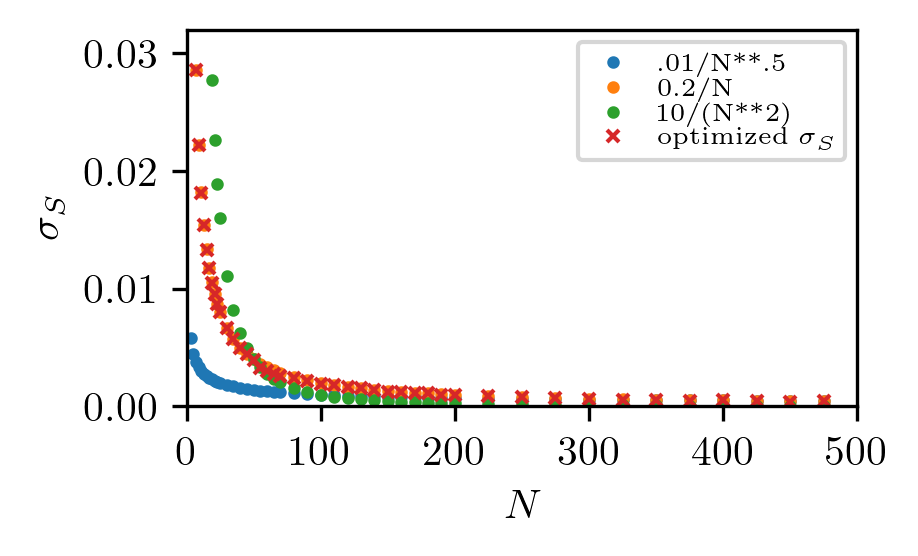

In [10]:
for i in [2, 5, 7]: #range(4, 10):
    plt.plot(NN, sig[:, i], "o", ms=2, label=lbls[i])
plt.plot(NN, sig[:, 0], "x", ms=3, label=r"optimized $\sigma_S$")
plt.legend()
plt.xlim(0, 500)
plt.ylim(0, 0.032)
plt.xlabel("$N$")
plt.ylabel(r"$\sigma_S$")